- ### Importação da base de dados e das bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('startups.csv', sep=';')

display(df)

,ID,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,0,Bytedance,140.0,07/04/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,1,SpaceX,100.3,01/12/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,2,Stripe,95.0,23/01/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
3,3,Klarna,45.6,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita..."
4,4,Canva,40.0,08/01/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."
...,...,...,...,...,...,...,...,...
1564,1564,SellerX,$1,12/09/2021,Germany,Berlin,Consumer & Retail,"Cherry Ventures, Felix Capital, 83North"
1565,1565,CloudBees,$1.15,12/09/2021,United States,San Jose,Enterprise Tech,"Matrix Partners, Lightspeed Venture Partners, ..."
1566,1566,Merama,$1.20,12/09/2021,Mexico,Mexico City,Consumer & Retail,"SoftBank Latin America Fund, Advent Internatio..."
1567,1567,ONE,$1.35,12/08/2021,Singapore,NaN,Media & Entertainment,"Temasek, Guggenheim Investments, Qatar Investm..."


- ### Verificando quais colunas possuí dados nulos

In [2]:
df.isnull().sum()

,0
ID,0
Company,0
Valuation ($B),0
Date Joined,0
Country,2
City,9
Industry,0
Investors,39


- ### Verificando dados nulos da coluna 'Investors'

In [3]:
df[df['Investors'].isnull()]

,ID,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
999,999,Wonderful,$2,03/12/2026,Israel,Tel Aviv,Enterprise Tech,NaN
1000,1000,Rhoda AI,$1.70,03/10/2026,United States,San Jose,Industrials,NaN
1003,1003,ArtIn Energy,$14.5,03/09/2026,United States,Tampa,Industrials,NaN
1010,1010,Global Eggs,$8,03/02/2026,Canada,Etobicoke,Industrials,NaN
1028,1028,humansand,$4.48,1/20/2026,United States,San Francisco,Enterprise Tech,NaN
1034,1034,Torq,$1.20,01/11/2026,Israel,Tel Aviv,Enterprise Tech,NaN
1044,1044,Fuse Energy,$5,12/18/2025,United Kingdom,London,Industrials,NaN
1046,1046,Radiant,$1.8,12/17/2025,United States,El Segundo,Industrials,NaN
1047,1047,Chai Discovery,$1.30,12/15/2025,United States,San Francisco,Enterprise Tech,NaN
1051,1051,ICEYE,$2.80,12/05/2025,Finland,Espoo,Enterprise Tech,NaN


- ### Preenche os investidores ausentes utilizando as empresas como referência

In [4]:
map_investors = {
    "Rhoda AI": "Capricorn Investment Group, Gigascale Capital, Hyperlink Ventures, John Doerr, Khosla Ventures, Mayfield, Temasek, Premji Invest",
    "firmus": "Coatue, NVIDIA",
    "Wayve": "SoftBank Group, Microsoft, NVIDIA",
    "NinjaOne": "ICONIQ Growth, CapitalG, Battery Ventures, Bessemer Venture Partners, Georgian, Summit Partners",
    "Helsing": "General Catalyst, Saab, Spotify CEO Daniel Ek, Lightspeed Venture Partners, Accel",
    "Imbue": "Astera Institute, NVIDIA, Cruise CEO Kyle Vogt, Notion Capital",
    "Wonderful": "CICC Capital, China Insurance Investment, China Mobile",
    "ArtIn Energy": "Fidelity Investments, ING, Innovation Industries",
    "Global Eggs": "AMD Ventures, Magnetar Capital, Maverick Silicon",
    "humansand": "Boston Scientific",
    "Torq": "Atlantico, Founders Fund, Kaszek",
    "Fuse Energy": "Undisclosed Investors",
    "Radiant": "AMD Ventures, GV, Greycroft",
    "Chai Discovery": "20VC, Abstract, Blackstone",
    "ICEYE": "Beijing Financial Street Capital Operation Center, CICC Capital",
    "MGT": "SnowPoint Ventures, Alumni Ventures",
    "Metropolis": "Felicis, First Round Capital, Joe Montana",
    "SheMed": "CPP Investments",
    "Chobani": "Gaorong Capital, HongShan, Tencent",
    "Vantaca": "AMD Ventures, Magnetar Capital, Maverick Silicon",
    "Raise Financial Services": "8VC, Bezos Expeditions, Bin Lin",
    "Unitree Robotics": "Benchmark, EQT Ventures, NFX",
    "Teamworks": "SC Ventures, MiddleGame Ventures",
    "Awardco": "Fidelity Investments, ING, Innovation Industries",
    "JSW One Platforms": "AMD Ventures, Amazon, EQT",
    "Owner": "Ant Group, Future Capital, Gaorong Capital",
    "SpreeAI": "Bessemer Venture Partners, HCLTech, Khosla Ventures",
    "The Bot Company": "Bedrock Capital, Infinite Capital, Khosla Ventures",
    "Aragen": "Asia Investment Capital, BAIC Capital, HighLight Capital",
    "The Row": "CICC Capital, China Insurance Investment, China Mobile",
    "Kiteworks": "Fidelity Investments, ING, Innovation Industries",
    "IntraBio": "First Round Capital, GV, ICONIQ Growth",
    "Truveta": "Felicis, First Round Capital, Joe Montana",
    "Tamara": "Alibaba Group, CATL, Guozhitou Private Equity Fund Management",
    "InCred": "CASVC Investment, China Internet Investment Fund, Hefei Hi-Tech Investment",
    "01.AI": "8VC, Bezos Expeditions, Bin Lin",
    "Quest Global": "BAL Ventures, Battery Ventures, Defiant",
    "Astronergy": "Ant Group, Bake Capital, Bank of China Asset Management",
    "Avenue One": "20VC, Abstract, Blackstone"
}

df['Investors'] = df['Investors'].fillna(df['Company'].map(map_investors))


- ### Estrutura do DataFrame e os tipos de dados das colunas

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1569 entries, 0 to 1568
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              1569 non-null   int64 
 1   Company         1569 non-null   object
 2   Valuation ($B)  1569 non-null   object
 3   Date Joined     1569 non-null   object
 4   Country         1567 non-null   object
 5   City            1560 non-null   object
 6   Industry        1569 non-null   object
 7   Investors       1569 non-null   object
dtypes: int64(1), object(7)
memory usage: 98.2+ KB


- ### Exibe os registros que possuem valores ausentes na coluna 'Country'

In [6]:
df[df['Country'].isnull()]

,ID,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
1279,1279,Quest Global,$1.8,08/08/2023,NaN,Singapore,Industrials,"BAL Ventures, Battery Ventures, Defiant"
1280,1280,Micro Connect,$1.70,08/02/2023,NaN,Hong Kong,Financial Services,"HongShan, Horizons Ventures, Lenovo Capital an..."


- ### Preenche os valores ausentes da coluna 'Country' utilizando a cidade como referência

In [7]:
map_pais = {
    "Singapore": "Singapore",
    "Hong Kong": "Hong Kong"
}

df['Country'] = df['Country'].fillna(df['City'].map(map_pais))

- ### Exibe os registros que possuem valores ausentes na coluna 'City'

In [8]:
df[df['City'].isnull()]

,ID,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
995,995,Nordic Knots,$2.2,3/26/2026,Sweden,NaN,Consumer & Retail,"Creades, Imaginary Ventures, Iris Ventures"
1105,1105,Tala Health,$1.20,7/15/2025,United States,NaN,Healthcare & Life Sciences,Sofreh Capital
1107,1107,Airalo,$1,07/10/2025,Singapore,NaN,Consumer & Retail,"CVC Capital Partners, Peak XV Partners"
1110,1110,The Open Platform,$1,07/03/2025,United Arab Emirates,NaN,Enterprise Tech,Ribbit Capital
1148,1148,Endless,$1,2/26/2025,United States,NaN,Enterprise Tech,Foresight Ventures
1233,1233,Humanity Protocol,$1,2/28/2024,Hong Kong,NaN,Financial Services,"Shima Capital, CMCC Global, MH Ventures"
1298,1298,Scroll,$1.80,3/14/2023,Seychelles,NaN,Financial Services,"OKX Ventures, Sequoia Capital China, IOSG"
1339,1339,Kredivo Holdings,$1.66,8/15/2022,Singapore,NaN,Financial Services,"Jungle Ventures, Square Peg Capital, OpenSpace..."
1567,1567,ONE,$1.35,12/08/2021,Singapore,NaN,Media & Entertainment,"Temasek, Guggenheim Investments, Qatar Investm..."


- ### Preenche os valores ausentes da coluna 'City' utilizando o país como referência

In [9]:
map_cidade = {
    "Singapore": "Singapore",
    "Hong Kong": "Hong Kong",
    "Sweden": "Stockholm",
    "United Arab Emirates": "Dubai",
    "Seychelles": "Victoria"
}

df['City'] = df['City'].fillna(df['Country'].map(map_cidade))

- ### Preenche os valores ausentes da coluna 'City' utilizando o nome da empresa como referência

In [10]:
map_cidade_usa = {
    "Tala Health": "San Francisco",
    "Endless": "San Francisco"
}

df['City'] = df['City'].fillna(df['Company'].map(map_cidade_usa))

- ### Padroniza os nomes das categorias da coluna 'Industry'

In [11]:
map_industry = {
    'Industrial': 'Industrials',
    'West Palm Beach': 'Other',
    'E-commerce & direct-to-consumer': 'E-commerce & Direct-to-Consumer',
    'Internet software & services': 'Internet Software & Services',
    'Supply chain, logistics, & delivery': 'Supply Chain, Logistics & Delivery',
    'Artificial intelligence': 'Artificial Intelligence',
    'Mobile & telecommunications': 'Mobile & Telecommunications',
    'Data management & analytics': 'Data Management & Analytics',
    'Auto & transportation': 'Auto & Transportation',
    'Consumer & retail': 'Consumer & Retail'
}

df['Industry'] = df['Industry'].replace(map_industry)

- ### Corrige registros com cidade e país invertidos

In [12]:
mask = (
    (df['Country'] == 'Santa Clara') &
    (df['City'] == 'United States')
)

df.loc[mask, 'Country'] = 'United States'
df.loc[mask, 'City'] = 'Santa Clara'

- ### Padronizando a coluna 'Date Joined' para o tipo datetime e criando a coluna 'Year'

In [13]:
df['Date Joined'] = pd.to_datetime(
    df['Date Joined'],
    format='mixed',
    dayfirst=True
)

df['Year'] = df['Date Joined'].dt.year.astype(int)

- ### Converte todos os valores para texto, remove o símbolo '$' e, em seguida, converte a coluna para o tipo numérico (float)

In [14]:
df['Valuation ($B)'] = (
    df['Valuation ($B)']
    .astype(str)
    .str.replace('$', '', regex=False)
)

df['Valuation ($B)'] = pd.to_numeric(df['Valuation ($B)'], errors='coerce')

- ### Engenharia de Atributos: Criação da coluna 'Continent'

In [15]:
map_continent = {
    'Argentina': 'South America',
    'Brazil': 'South America',
    'Chile': 'South America',
    'Colombia': 'South America',
    'Ecuador': 'South America',
    'Canada': 'North America',
    'United States': 'North America',
    'Mexico': 'North America',
    'Bermuda': 'North America',
    'Cayman Islands': 'Central America',
    'Austria': 'Europe',
    'Belgium': 'Europe',
    'Croatia': 'Europe',
    'Czech Republic': 'Europe',
    'Denmark': 'Europe',
    'Estonia': 'Europe',
    'Finland': 'Europe',
    'France': 'Europe',
    'Germany': 'Europe',
    'Greece': 'Europe',
    'Ireland': 'Europe',
    'Italy': 'Europe',
    'Liechtenstein': 'Europe',
    'Lithuania': 'Europe',
    'Luxembourg': 'Europe',
    'Malta': 'Europe',
    'Netherlands': 'Europe',
    'Norway': 'Europe',
    'Portugal': 'Europe',
    'Spain': 'Europe',
    'Sweden': 'Europe',
    'Switzerland': 'Europe',
    'United Kingdom': 'Europe',
    'China': 'Asia',
    'Hong Kong': 'Asia',
    'India': 'Asia',
    'Indonesia': 'Asia',
    'Israel': 'Asia',
    'Japan': 'Asia',
    'Malaysia': 'Asia',
    'Philippines': 'Asia',
    'Saudi Arabia': 'Asia',
    'Singapore': 'Asia',
    'South Korea': 'Asia',
    'Thailand': 'Asia',
    'Turkey': 'Asia',
    'United Arab Emirates': 'Asia',
    'Uzbekistan': 'Asia',
    'Vietnam': 'Asia',
    'Egypt': 'Africa',
    'Nigeria': 'Africa',
    'Senegal': 'Africa',
    'Seychelles': 'Africa',
    'South Africa': 'Africa',
    'Australia': 'Oceania',
    'New Zealand': 'Oceania'
}

df['Continent'] = df['Country'].map(map_continent)


- ### Agrupa os dados por cidade e país, calcula a quantidade de empresas unicórnio e a soma das valuations, ordenando as 20 cidades com maior número de empresas

In [16]:
cidades = (
    df.groupby(['City', 'Country'])
    .agg(
        Qtd = ('ID', 'count'),
        Valuation = ('Valuation ($B)', 'sum')
    )
    .sort_values('Qtd', ascending=False)
    .nlargest(20, 'Qtd')
)

cidades

,,Qtd,Valuation
City,Country,,
San Francisco,United States,245,1972.17
New York,United States,142,367.87
Beijing,China,69,306.80
London,United Kingdom,54,180.47
Shanghai,China,47,121.40
Palo Alto,United States,35,115.77
Bengaluru,India,32,88.75
Paris,France,27,71.37
Shenzhen,China,24,78.97


- ### DataFrame das empresas unicórnio do Brasil

In [17]:
brasil = df[df['Country'] == 'Brazil']

brasil

,ID,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors,Year,Continent
8,8,Nubank,30.00,2018-03-01,Brazil,Sao Paulo,Fintech,"Sequoia Capital, Redpoint e.ventures, Kaszek V...",2018,South America
111,111,QuintoAndar,5.10,2019-09-09,Brazil,Campinas,E-commerce & Direct-to-Consumer,"Kaszek Ventures, General Atlantic, SoftBank Group",2019,South America
112,112,C6 Bank,5.05,2020-12-02,Brazil,Sao Paulo,Fintech,Credit Suisse,2020,South America
223,223,Nuvemshop,3.10,2021-08-17,Brazil,Sao Paulo,E-commerce & Direct-to-Consumer,"Kaszek Ventures, Qualcomm Ventures, Accel",2021,South America
233,233,Wildlife Studios,3.00,2019-12-05,Brazil,Sao Paulo,Other,"Benchmark, Bessemer Venture Partners",2019,South America
264,264,Loft,2.90,2020-01-03,Brazil,Sao Paulo,E-commerce & Direct-to-Consumer,"Monashees+, Andreessen Horowitz, QED Investors",2020,South America
338,338,1,2.15,2021-09-08,Brazil,Sao Paulo,Fintech,"Plug and Play Ventures, Valor Capital Group, D...",2021,South America
385,385,Loggi,2.00,2019-06-05,Brazil,Sao Paulo,"Supply Chain, Logistics & Delivery","Qualcomm Ventures, SoftBank Group. Monashees+",2019,South America
430,430,Creditas,1.75,2020-12-18,Brazil,Sao Paulo,Fintech,"Kaszek Ventures, Amadeus Capital Partners, Quo...",2020,South America
744,744,Movile,1.00,2018-07-12,Brazil,Sao Paulo,Mobile & Telecommunications,"Innova Capital - FIP, 3G Capital Management, P...",2018,South America


- ### Agrupa as empresas unicórnio do Brasil por ano e calcula a quantidade de empresas e a soma das valuations (em bilhões de dólares)

In [18]:
brasil_yearly_unicorns = (
    brasil.groupby(['Country', 'Year'])
    .agg(
        qtd = ('ID', 'count'),
        valuation = ('Valuation ($B)', 'sum')
    )
    .reset_index()
)

brasil_yearly_unicorns

,Country,Year,qtd,valuation
0,Brazil,2018,3,32.00
1,Brazil,2019,4,11.10
2,Brazil,2020,3,9.70
3,Brazil,2021,6,9.75
4,Brazil,2022,2,2.88
5,Brazil,2023,1,1.00
6,Brazil,2026,1,1.30


- ### Análise YoY das Empresas

In [19]:
yoy_companies = (
    df.groupby('Year')
    .agg(Qtd=('ID', 'count'))
    .reset_index()
)

yoy_companies['Qtd Ano Anterior'] = yoy_companies['Qtd'].shift(1)

yoy_companies['YoY (%)'] = (
    (yoy_companies['Qtd'] - yoy_companies['Qtd Ano Anterior']) / yoy_companies['Qtd Ano Anterior']
) * 100

yoy_companies['YoY (%)'] = yoy_companies['YoY (%)'].round(2)
yoy_companies

,Year,Qtd,Qtd Ano Anterior,YoY (%)
0,2007,1,NaN,NaN
1,2010,1,1.0,0.00
2,2011,2,1.0,100.00
3,2012,4,2.0,100.00
4,2013,3,4.0,-25.00
5,2014,13,3.0,333.33
6,2015,37,13.0,184.62
7,2016,22,37.0,-40.54
8,2017,46,22.0,109.09
9,2018,107,46.0,132.61


- ### Análise YoY do Valuation ($ Bilhões)

In [20]:
yoy_valuation = (
    df.groupby('Year')
    .agg(Valuation=('Valuation ($B)', 'sum'))
    .reset_index()
)

yoy_valuation['Valuation Ano Anterior'] = yoy_valuation['Valuation'].shift(1)

yoy_valuation['YoY (%)'] = (
    (yoy_valuation['Valuation'] - yoy_valuation['Valuation Ano Anterior'])
    / yoy_valuation['Valuation Ano Anterior']
) * 100

yoy_valuation['YoY (%)'] = yoy_valuation['YoY (%)'].round(2)
yoy_valuation

,Year,Valuation,Valuation Ano Anterior,YoY (%)
0,2007,1.38,NaN,NaN
1,2010,3.00,1.38,117.39
2,2011,51.30,3.00,1610.00
3,2012,122.30,51.30,138.40
4,2013,4.30,122.30,-96.48
5,2014,165.38,4.30,3746.05
6,2015,99.55,165.38,-39.81
7,2016,81.04,99.55,-18.59
8,2017,296.14,81.04,265.42
9,2018,495.47,296.14,67.31


- ### Objetivo: Identificar a quantidade de países, quantidade de empresas e o valuation por continente

In [21]:
continentes = (
    df.groupby('Continent')
    .agg(
        Qtd_Paises=('Country', 'nunique'),
        Qtd_Empresas=('ID', 'count'),
        Valuation_Bilhoes=('Valuation ($B)', 'sum')
    )
    .sort_values('Qtd_Paises', ascending=False)
    .reset_index()
)

continentes

,Continent,Qtd_Paises,Qtd_Empresas,Valuation_Bilhoes
0,Europe,23,214,624.15
1,Asia,16,402,1149.22
2,Africa,5,8,44.49
3,South America,5,27,81.58
4,North America,4,906,3796.83
5,Oceania,2,11,62.27
6,Central America,1,1,1.00


- ### Criação da tabela 'investidores' separando cada investidor em uma linha

In [22]:
investidores = (
    df[['Company', 'Country', 'Industry', 'Valuation ($B)', 'Investors']]
    .assign(Investor=df['Investors'].str.split(','))
    .explode('Investor')
)

investidores['Investor'] = investidores['Investor'].str.strip()
investidores = investidores[['Company', 'Investor', 'Country', 'Industry', 'Valuation ($B)']]
investidores

,Company,Investor,Country,Industry,Valuation ($B)
0,Bytedance,Sequoia Capital China,China,Artificial Intelligence,140.00
0,Bytedance,SIG Asia Investments,China,Artificial Intelligence,140.00
0,Bytedance,Sina Weibo,China,Artificial Intelligence,140.00
0,Bytedance,Softbank Group,China,Artificial Intelligence,140.00
1,SpaceX,Founders Fund,United States,Other,100.30
...,...,...,...,...,...
1567,ONE,Guggenheim Investments,Singapore,Media & Entertainment,1.35
1567,ONE,Qatar Investment Authority,Singapore,Media & Entertainment,1.35
1568,Lydia,NewAlpha,France,Financial Services,1.00
1568,Lydia,XAnge Private Equity,France,Financial Services,1.00


- ### Objetivo: Identificar os investidores com maior número de empresas investidas e os investidores associados aos maiores valuations.




In [23]:
tot_investors = (
    investidores
    .groupby('Investor')
    .agg(
        Qtd=('Company', 'count'),
        Valuation=('Valuation ($B)', 'sum')
    )
    .sort_values('Qtd', ascending=False)
    .nlargest(20, 'Qtd')
    .reset_index()
)

tot_investors

,Investor,Qtd,Valuation
0,Andreessen Horowitz,87,351.70
1,Accel,81,264.90
2,Sequoia Capital,75,419.15
3,Tiger Global Management,58,148.55
4,General Catalyst,58,176.34
5,Insight Partners,55,138.63
6,Lightspeed Venture Partners,54,156.25
7,Sequoia Capital China,49,337.18
8,Bessemer Venture Partners,41,97.62
9,Index Ventures,41,110.25


- ### Objetivo: Identificar quais setores atraíram o maior número de investidores diferentes

In [24]:
industry_investors = (
    investidores
    .groupby('Industry')
    .agg(Qtd_Investidores=('Investor', 'nunique'))
    .sort_values('Qtd_Investidores', ascending=False)
    .reset_index()
)

industry_investors

,Industry,Qtd_Investidores
0,Enterprise Tech,416
1,Fintech,355
2,Internet Software & Services,268
3,Industrials,233
4,E-commerce & Direct-to-Consumer,205
5,Financial Services,186
6,Consumer & Retail,182
7,Artificial Intelligence,160
8,Health,141
9,"Supply Chain, Logistics & Delivery",129


In [25]:
graf_industry = px.bar(
    industry_investors,
    x='Qtd_Investidores',
    y='Industry',
    category_orders={'Qtd_Investidores': industry_investors['Qtd_Investidores'].tolist()},
    labels={'Industry': 'Setor'},
    text='Qtd_Investidores',
    title='Setores que atraíram o maior número de investidores'
)

graf_industry.update_layout(
    yaxis=dict(autorange='reversed'),
    title=dict(xanchor='center', x=0.4, xref='paper')
)
graf_industry.update_traces(textposition='outside')

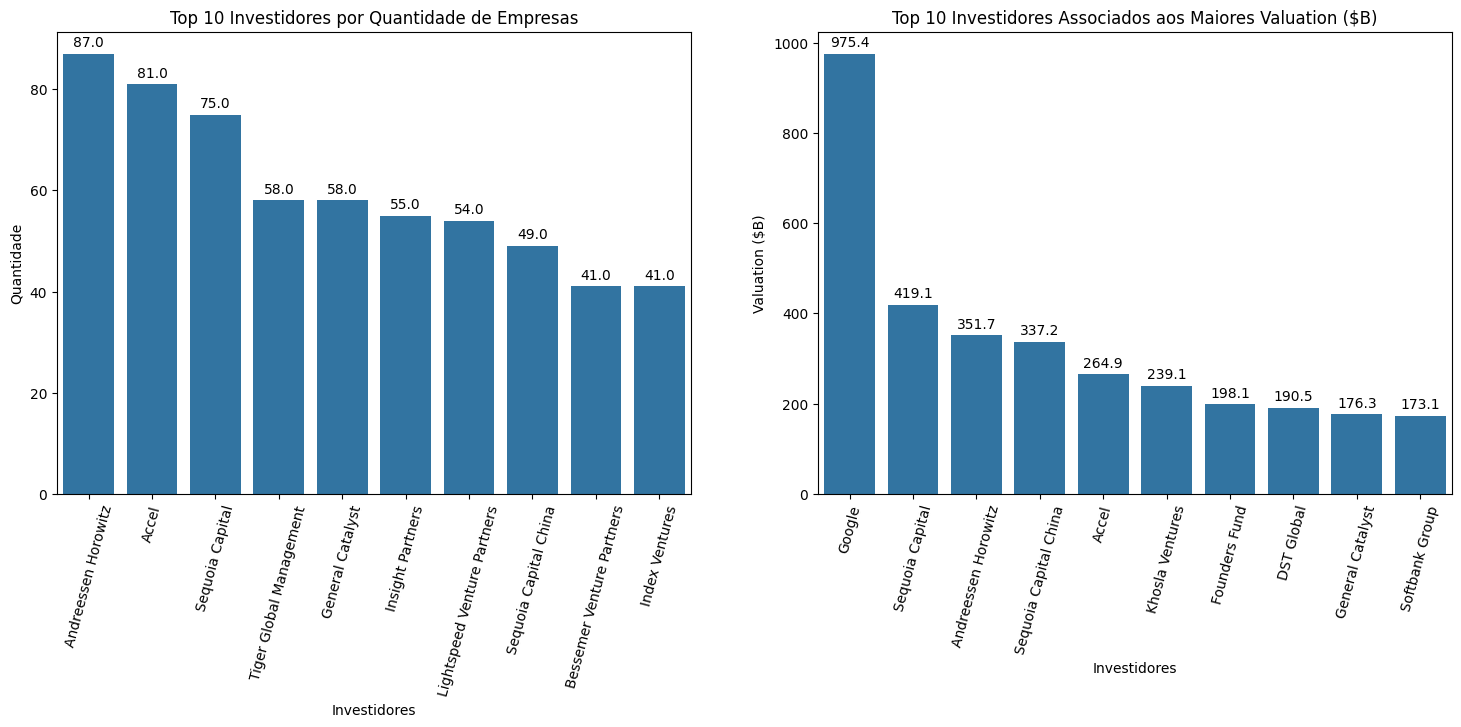

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

top10_investors = tot_investors.head(10)
top10_investors_val = (
    investidores
    .groupby('Investor', as_index=False)
    .agg(Valuation=('Valuation ($B)', 'sum'))
    .sort_values('Valuation', ascending=False)
    .nlargest(10, 'Valuation')
)

# Gráfico 1
sns.barplot(
    data=top10_investors,
    x='Investor',
    y='Qtd',
    ax=ax[0]
)

ax[0].set_title('Top 10 Investidores por Quantidade de Empresas')
ax[0].set_xlabel('Investidores')
ax[0].set_ylabel('Quantidade')
ax[0].tick_params(axis='x', rotation=75)
ax[0].bar_label(ax[0].containers[0], fmt='%.1f', padding=3)

# Gráfico 2
sns.barplot(
    data=top10_investors_val,
    x='Investor',
    y='Valuation',
    ax=ax[1]
)

ax[1].set_title('Top 10 Investidores Associados aos Maiores Valuation ($B)')
ax[1].set_xlabel('Investidores')
ax[1].set_ylabel('Valuation ($B)')
ax[1].tick_params(axis='x', rotation=75)
ax[1].bar_label(ax[1].containers[0], fmt='%.1f', padding=3);

- ### Análise por continente

In [27]:
# Gráfico 1

continentes = continentes.sort_values('Qtd_Paises', ascending=False)

graf1 = px.bar(
    continentes,
    y='Continent',
    x='Qtd_Paises',
    category_orders={'Qtd_Paises': continentes['Qtd_Paises'].tolist()},
    text='Qtd_Paises',
    title='Continentes com mais países com Empresas Unicórnios'
)

graf1.update_layout(
    yaxis=dict(autorange='reversed'),
    title=dict(xanchor='center', x=0.5, xref='paper')
)
graf1.update_traces(textposition='outside')
graf1.show()

# Gráfico 2

continentes = continentes.sort_values('Qtd_Empresas', ascending=False)

graf2 = px.bar(
    continentes,
    y='Continent',
    x='Qtd_Empresas',
    category_orders={'Qtd_Empresas': continentes['Qtd_Empresas'].tolist()},
    text='Qtd_Empresas',
    title='Continentes com mais Empresas Unicórnios'
)

graf2.update_layout(
    yaxis=dict(autorange='reversed'),
    title=dict(xanchor='center', x=0.5, xref='paper')
)
graf2.update_traces(textposition='outside')
graf2.show()

In [28]:
south_america = df[df['Continent'] == 'South America']

south_america = (
    south_america.groupby(['Continent', 'Year'])
    .agg(Qtd_Empresas=('Continent', 'count'))
    .reset_index()
)

south_america

,Continent,Year,Qtd_Empresas
0,South America,2015,1
1,South America,2018,4
2,South America,2019,4
3,South America,2020,3
4,South America,2021,8
5,South America,2022,5
6,South America,2023,1
7,South America,2026,1


In [29]:
# Adicionar coordenadas aproximadas para o centro de cada continente
continent_coords = {
    'Europe': {'lat': 54.5260, 'lon': 15.2551},
    'Asia': {'lat': 34.0479, 'lon': 100.6197},
    'Africa': {'lat': -8.7832, 'lon': 34.5085},
    'South America': {'lat': -14.2350, 'lon': -51.9253},
    'North America': {'lat': 54.5260, 'lon': -105.2551},
    'Oceania': {'lat': -25.2744, 'lon': 133.7751},
    'Central America': {'lat': 15.7835, 'lon': -90.1500} # Aproximação para a região
}

# Criar um DataFrame de coordenadas para facilitar a junção
coords_df = pd.DataFrame([
    {'Continent': k, 'lat': v['lat'], 'lon': v['lon']}
    for k, v in continent_coords.items()
])

# Unir os dados dos continentes com as coordenadas
continentes_com_coords = continentes.merge(coords_df, on='Continent', how='left')

# Criar o mapa scatter_geo
graf_mapa_continentes_scatter = px.scatter_geo(
    continentes_com_coords,
    lat='lat',
    lon='lon',
    size='Qtd_Empresas',
    size_max=60,
    color='Qtd_Empresas',
    hover_name='Continent',
    projection='natural earth',
    title='Quantidade de Empresas Unicórnio por Continente',
    color_continuous_scale='Blues'
)

graf_mapa_continentes_scatter.update_geos(
    showland=True,
    landcolor="#2E2E2E",
    showocean=True,
    oceancolor="#0E1117",
    showcountries=True,
    countrycolor="#666666",
    coastlinecolor="#888888"
)

graf_mapa_continentes_scatter.update_layout(
    paper_bgcolor="#0E1117",
    plot_bgcolor="#0E1117",
    font_color="white",
    title=dict(xanchor='center', x=0.5, xref='paper')
)

graf_mapa_continentes_scatter.show()

- ### Objetivo: Analisar a evolução acumulada do número de empresas unicórnio por indústria entre 2020 e 2026, identificando os setores que mais expandiram sua participação ao longo dos últimos anos.

In [30]:
industry_evolution = (
    df[df['Year'].between(2020, 2026)]
    .groupby(['Industry', 'Year'])['ID']
    .count()
    .reset_index()
)

industry_evolution['total_acumulado'] = (
    industry_evolution
    .groupby('Industry')['ID']
    .cumsum()
)

top_industries = (
    industry_evolution
    .groupby('Industry')['total_acumulado']
    .max()
    .nlargest(5)
    .index
)

industry_top = industry_evolution[
    industry_evolution['Industry'].isin(top_industries)
]

px.line(
    industry_top,
    x='Year',
    y='total_acumulado',
    color='Industry',
    markers=True,
     labels={
        'Year': 'Ano',
        'total_acumulado': 'Empresas Acumuladas',
        'Industry': 'Indústria'
    },
    title='Evolução Acumulada dos 5 Principais Setores de Empresas Unicórnio que Mais Cresceram nos Últimos Anos'
)

In [31]:
df.to_csv('startups_2007_2026.csv', index=False)